Google Play Store Data Analysis Project

# **Google Play Store Data Analysis Using Python**


# **Objective**

*  ** To analyze Google Play Store data using Python and identify patterns in app popularity, installations, reviews, ratings, pricing, and app size. **



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Play Store Data project set to Play Store Data project set


In [ ]:
df = pd.read_csv(next(iter(uploaded)))
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
#check the size of the data set
print("rows and columns:", df.shape)

# check column names
print("\ncolumn names:")
print(df.columns.tolist())

# Check data types and non-null values
print("\ndataset information:")
df.info()

rows and columns: (10841, 13)

column names:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  objec

In [ ]:
# Check missing values
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
# Check duplicate rows
print("duplicate rows:", df.duplicated().sum())

duplicate rows: 483


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()
print("shape after removing duplicates:", df.shape)

shape after removing duplicates: (10358, 13)


In [ ]:
# check the minimum and maximum rating
print("minimum Rating:", df['Rating'].min())
print("maximum Rating:", df['Rating'].max())

minimum Rating: 1.0
maximum Rating: 19.0


In [ ]:
# Find ratings greater than 5
df[df['Rating']>5][['App','Rating']]

,App,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,19.0


In [ ]:
# Replace invalide ratings with NaN
df.loc[df['Rating']>5, 'Rating'] = np.nan

# Check again
print("maximum Rating:",df['Rating'].max())

maximum Rating: 5.0


In [ ]:
print("missing ratings:", df['Rating'].isnull().sum())

missing ratings: 1466


In [ ]:
# Check the reviews column
print(df['Reviews'].dtype)
print(df['Reviews'].head())

object
0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: object


In [ ]:
# convert reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'],errors='coerce')
print("Reviews data type:", df['Reviews'].dtype)

Reviews data type: float64


In [ ]:
# check the installs columns
print(df['Installs'].dtype)
print(df['Installs'].head())

object
0        10,000+
1       500,000+
2     5,000,000+
3    50,000,000+
4       100,000+
Name: Installs, dtype: object


In [ ]:
#remove + and commas, then convert to numeric
df['Installs'] = df['Installs'].str.replace('+','',regex=False)
df['Installs'] = df['Installs'].str.replace(',','',regex=False)
df['Installs'] = pd.to_numeric(df['Installs'],errors='coerce')
print("Installs data type:", df['Installs'].dtype)
print(df['Installs'].head())

Installs data type: float64
0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64


In [ ]:
print("Minimum installs:", df['Installs'].min())
print("Maximum installs:", df['Installs'].max())


Minimum installs: 0.0
Maximum installs: 1000000000.0


In [ ]:
# Check price column
print(df['Price'].dtype)
print(df['Price'].head())

object
0    0
1    0
2    0
3    0
4    0
Name: Price, dtype: object


In [ ]:
# Remove $ sign and convert price to numeric
df['Price'] = df['Price'].astype(str).str.replace('$','',regex=False)
df['Price'] = pd.to_numeric(df['Price'],errors='coerce')
print("Price data type:", df['Price'].dtype)
print(df['Price'].head())

Price data type: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


In [ ]:
print("Minimum price:", df['Price'].min())
print("Maximum price:", df['Price'].max())

Minimum price: 0.0
Maximum price: 400.0


In [ ]:
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == 'Varies with device':
        return np.nan

    if size.endswith('M'):
        return float(size[:-1])

    if size.endswith('k'):
        return float(size[:-1]) / 1024

    return np.nan


df['Size_MB'] = df['Size'].apply(convert_size)

print(df[['Size', 'Size_MB']].head(10))

   Size  Size_MB
0   19M     19.0
1   14M     14.0
2  8.7M      8.7
3   25M     25.0
4  2.8M      2.8
5  5.6M      5.6
6   19M     19.0
7   29M     29.0
8   33M     33.0
9  3.1M      3.1


In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
App                  0
Category             0
Rating            1466
Reviews              1
Size                 0
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
Size_MB           1527
dtype: int64


In [ ]:
# Fill missing Rating values with the median rating
df['Rating'] = df['Rating'].fillna(df['Rating'].median())

# Fill missing text values with "Unknown"
text_columns = ['Category', 'Reviews', 'Installs', 'Type', 'Price',
                'Current Ver', 'Android Ver']

for col in text_columns:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill missing Size_MB with the median size
df['Size_MB'] = df['Size_MB'].fillna(df['Size_MB'].median())

# Check missing values again
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_MB           0
dtype: int64


In [ ]:
# fill missing content rating
df['Content Rating'] = df['Content Rating'].fillna('Unknown')

# Check missing values again
print("Missing values after final cleaning:")
print(df.isnull().sum())

Missing values after final cleaning:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_MB           0
dtype: int64


In [ ]:
#Check data types of all columns
print("data types:")
print(df.dtypes)

data types:
App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
Size_MB           float64
dtype: object


In [ ]:
# Check dataset shape and information
print("Dataset Shape:", df.shape)
print("\Dataset Information:")
df.info()

Dataset Shape: (10358, 14)
\Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          10358 non-null  float64
 3   Reviews         10358 non-null  object 
 4   Size            10358 non-null  object 
 5   Installs        10358 non-null  object 
 6   Type            10358 non-null  object 
 7   Price           10358 non-null  object 
 8   Content Rating  10358 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10358 non-null  object 
 12  Android Ver     10358 non-null  object 
 13  Size_MB         10358 non-null  float64
dtypes: float64(2), object(12)
memory usage: 1.2+ MB


<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_595/1024590999.py:3: SyntaxWarning: invalid escape sequence '\D'
  print("\Dataset Information:")


In [ ]:
# Check numbers of unique values in each column
print("Unique Values:")
print(df.nunique())

Unique Values:
App               9660
Category            34
Rating              39
Reviews           6002
Size               462
Installs            21
Type                 4
Price               93
Content Rating       7
Genres             120
Last Updated      1378
Current Ver       2833
Android Ver         34
Size_MB            459
dtype: int64


In [ ]:
# Check unique values in important categorical columns

print("Type:", df['Type'].unique())
print("Content Rating:", df['Content Rating'].unique())
print("Category:", df['Category'].nunique())

Type: ['Free' 'Paid' 'Unknown' '0']
Content Rating: ['Everyone' 'Teen' 'Everyone 10+' 'Mature 17+' 'Adults only 18+' 'Unrated'
 'Unknown']
Category: 34


In [ ]:
print("Top 10 Categories:")
print(df['Category'].value_counts().head(10))

Top 10 Categories:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


In [ ]:
print("App Type Distribution:")
print(df['Type'].value_counts())

App Type Distribution:
Type
Free       9591
Paid        765
Unknown       1
0             1
Name: count, dtype: int64


In [ ]:
print("Content Rating Distribution:")
print(df['Content Rating'].value_counts())


Content Rating Distribution:
Content Rating
Everyone           8382
Teen               1146
Mature 17+          447
Everyone 10+        377
Adults only 18+       3
Unrated               2
Unknown               1
Name: count, dtype: int64


In [ ]:
print("Average Rating:",round(df['Rating'].mean(),2))

Average Rating: 4.2


In [ ]:
# convert installs to numeric
df['Installs'] = pd.to_numeric(df['Installs'],errors='coerce')

print("Installs data type:",df['Installs'].dtype)

Installs data type: float64


In [ ]:
print("Top 10 Apps by Installs:")
print(df[['App','Installs']].sort_values('Installs',ascending=False).head(10))

Top 10 Apps by Installs:
                            App      Installs
3454               Google Drive  1.000000e+09
865           Google Play Games  1.000000e+09
3523               Google Drive  1.000000e+09
2544                   Facebook  1.000000e+09
2545                  Instagram  1.000000e+09
464                    Hangouts  1.000000e+09
3223  Maps - Navigate & Explore  1.000000e+09
3816                Google News  1.000000e+09
4170               Google Drive  1.000000e+09
3896             Subway Surfers  1.000000e+09


In [ ]:
print("Average Rating by App Type:")
print(df.groupby('Type')['Rating'].mean().round(2))

Average Rating by App Type:
Type
0          4.30
Free       4.20
Paid       4.27
Unknown    4.30
Name: Rating, dtype: float64


In [ ]:
# Convert reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'],errors='coerce')

print("Reviews data type:",df['Reviews'].dtype)

Reviews data type: float64


In [ ]:
print("Top 10 Apps by Reviews:")
print(df[['App','Reviews']].sort_values('Reviews',ascending=False).head(10))

Top 10 Apps by Reviews:
                                           App     Reviews
2544                                  Facebook  78158306.0
3943                                  Facebook  78128208.0
336                         WhatsApp Messenger  69119316.0
3904                        WhatsApp Messenger  69109672.0
2604                                 Instagram  66577446.0
2545                                 Instagram  66577313.0
3909                                 Instagram  66509917.0
382   Messenger – Text and Video Chat for Free  56646578.0
335   Messenger – Text and Video Chat for Free  56642847.0
1879                            Clash of Clans  44893888.0


In [ ]:
print("Average Reviews by App Type:")
print(df.groupby('Type')['Reviews'].mean().round(0))


Average Reviews by App Type:
Type
0               NaN
Free       437374.0
Paid        11901.0
Unknown         0.0
Name: Reviews, dtype: float64


In [ ]:
print("Top 10 Categories by Reviews:")
print(df.groupby('Category')['Reviews'].sum().sort_values(ascending=False).head(10))

Top 10 Categories by Reviews:
Category
GAME               1.415537e+09
COMMUNICATION      6.012736e+08
SOCIAL             5.335768e+08
FAMILY             3.967720e+08
TOOLS              2.731850e+08
PHOTOGRAPHY        2.042974e+08
VIDEO_PLAYERS      1.103802e+08
PRODUCTIVITY       1.025545e+08
SHOPPING           9.493116e+07
PERSONALIZATION    7.519316e+07
Name: Reviews, dtype: float64


In [ ]:
print("Average Installs by App Type:")
print(df.groupby('Type')['Installs'].mean().round(0))

Average Installs by App Type:
Type
0                 NaN
Free       15281273.0
Paid          90491.0
Unknown           0.0
Name: Installs, dtype: float64


In [ ]:
print("Average Rating by Category:")
print(df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10).round(2))

Average Rating by Category:
Category
EVENTS                 4.40
EDUCATION              4.38
ART_AND_DESIGN         4.36
BOOKS_AND_REFERENCE    4.34
PERSONALIZATION        4.33
1.9                    4.30
PARENTING              4.30
BEAUTY                 4.28
GAME                   4.28
HEALTH_AND_FITNESS     4.27
Name: Rating, dtype: float64


In [ ]:
print("Average Reviews by Category:")
print(df.groupby('Category')['Reviews'].mean().sort_values(ascending=False).head(10).round(0))


Average Reviews by Category:
Category
SOCIAL              1905632.0
COMMUNICATION       1642824.0
GAME                1262745.0
PHOTOGRAPHY          634464.0
VIDEO_PLAYERS        630744.0
ENTERTAINMENT        428565.0
SHOPPING             423800.0
TOOLS                324063.0
PRODUCTIVITY         251977.0
TRAVEL_AND_LOCAL     234452.0
Name: Reviews, dtype: float64


In [ ]:
print("Average Installs by Category:")
print(df.groupby('Category')['Installs'].mean().sort_values(ascending=False).head(10).round(0))

Average Installs by Category:
Category
COMMUNICATION         65989826.0
SOCIAL                44692385.0
VIDEO_PLAYERS         35554301.0
PRODUCTIVITY          30621846.0
PHOTOGRAPHY           30190210.0
GAME                  28139183.0
TRAVEL_AND_LOCAL      26843406.0
ENTERTAINMENT         22123063.0
NEWS_AND_MAGAZINES    20428855.0
TOOLS                 13585732.0
Name: Installs, dtype: float64


In [ ]:
print("Free vs Paid - Average Rating:")
print(df[df['Type'].isin(['Free','Paid'])].groupby('Type')['Rating'].mean().round(2))

Free vs Paid - Average Rating:
Type
Free    4.20
Paid    4.27
Name: Rating, dtype: float64


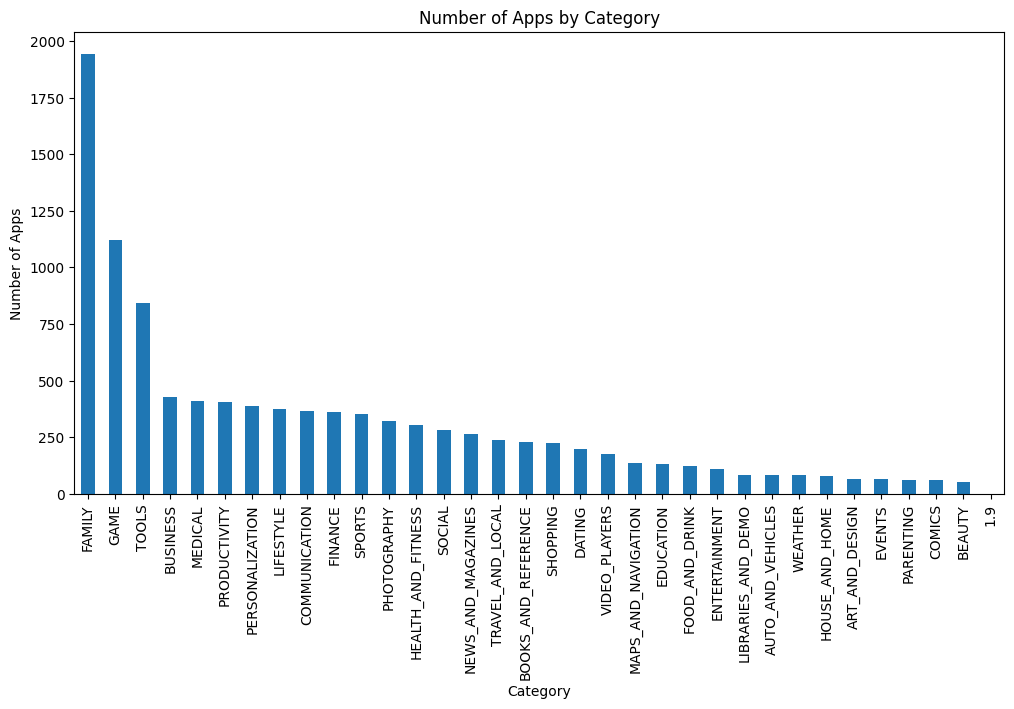

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df['Category'].value_counts().plot(kind='bar')
plt.title('Number of Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=90)
plt.show()

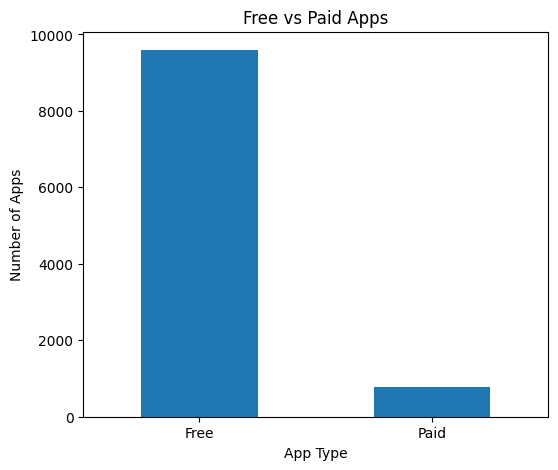

In [ ]:
plt.figure(figsize=(6, 5))
df[df['Type'].isin(['Free','Paid'])]['Type'].value_counts().plot(kind='bar')
plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)
plt.show()

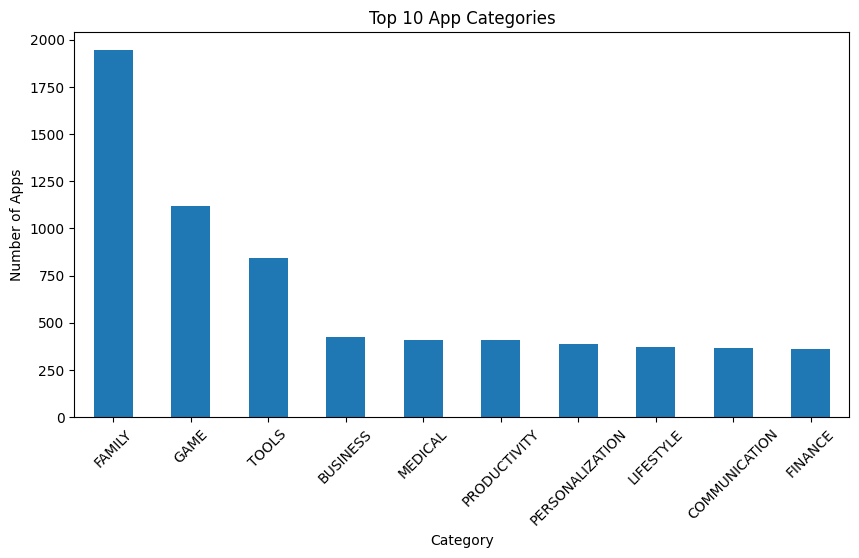

In [ ]:
top_categories = df['Category'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_categories.plot(kind='bar')
plt.title('Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.show()

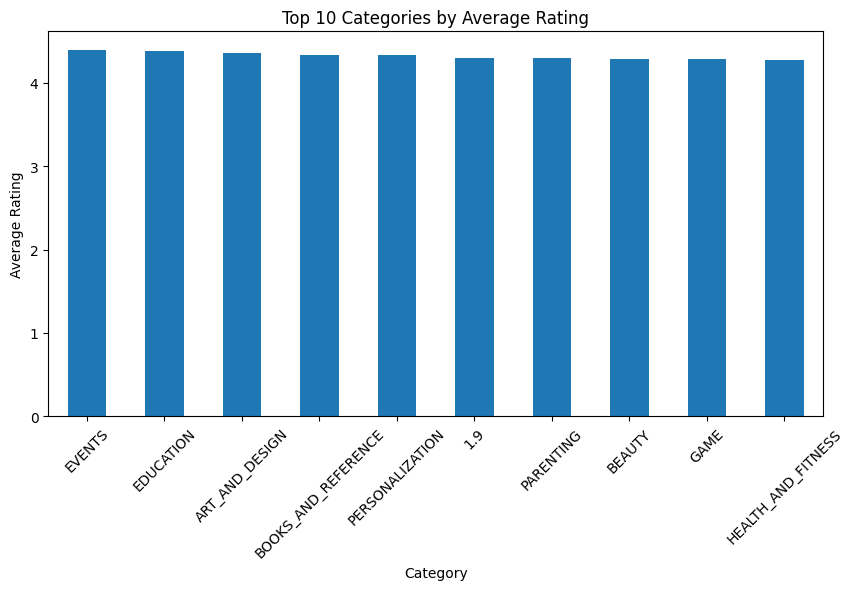

In [ ]:
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
avg_rating.plot(kind='bar')
plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

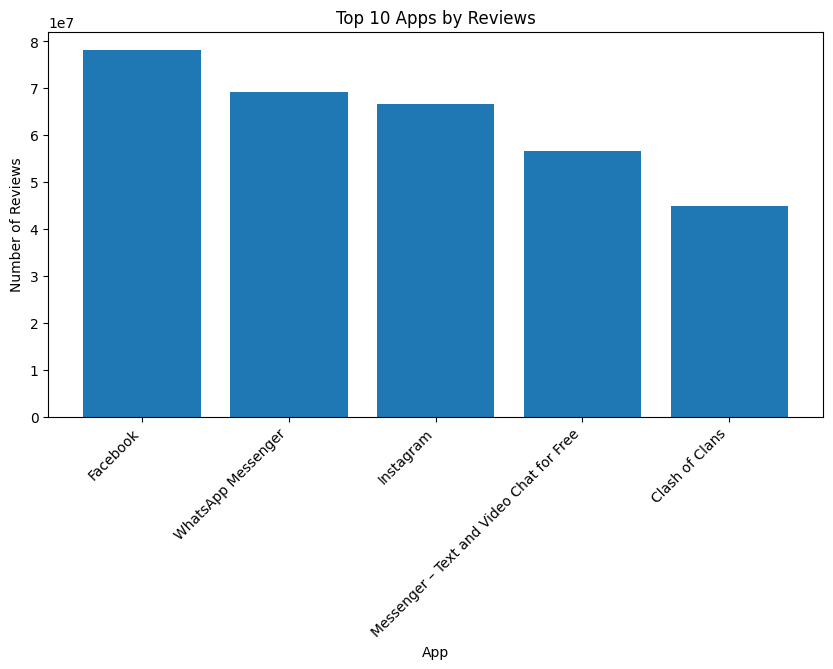

In [ ]:
top_reviews = df[['App','Reviews']].sort_values('Reviews',ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_reviews['App'], top_reviews['Reviews'])
plt.title('Top 10 Apps by Reviews')
plt.xlabel('App')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.show()

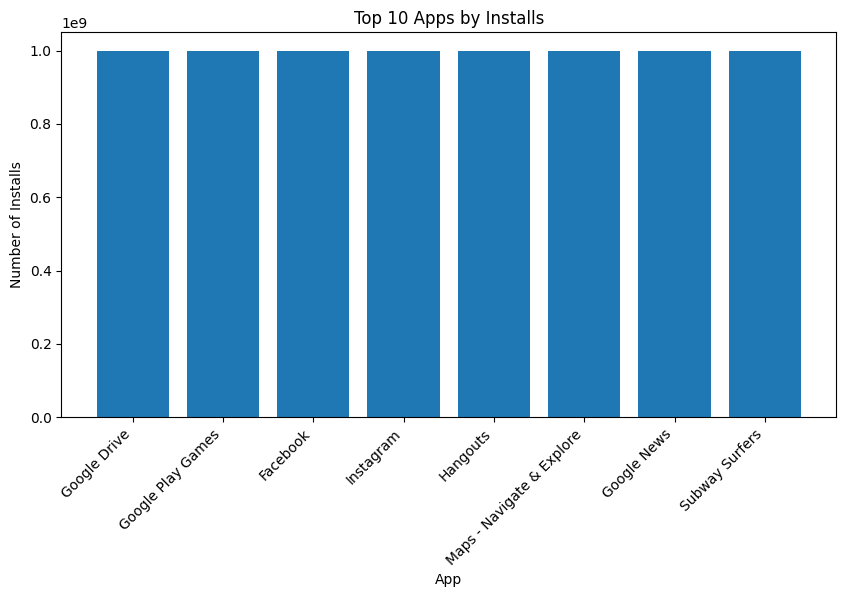

In [ ]:
top_installs = df[['App','Installs']].sort_values('Installs',ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_installs['App'], top_installs['Installs'])
plt.title('Top 10 Apps by Installs')
plt.xlabel('App')
plt.ylabel('Number of Installs')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# Correlation between numerical columns

numeric_cols = ['Rating', 'Reviews', 'Installs', 'Price']

correlation = df[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation.round(2))

Correlation Matrix:
          Rating  Reviews  Installs  Price
Rating      1.00     0.06      0.04  -0.02
Reviews     0.06     1.00      0.63  -0.01
Installs    0.04     0.63      1.00  -0.01
Price      -0.02    -0.01     -0.01   1.00


In [ ]:
# Convert numerical columns to numeric

for col in ['Rating', 'Reviews', 'Installs', 'Price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[['Rating', 'Reviews', 'Installs', 'Price']].dtypes)

Rating      float64
Reviews     float64
Installs    float64
Price       float64
dtype: object


In [ ]:
print(df.shape)
print(df.columns)

(10358, 14)
Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB'],
      dtype='object')


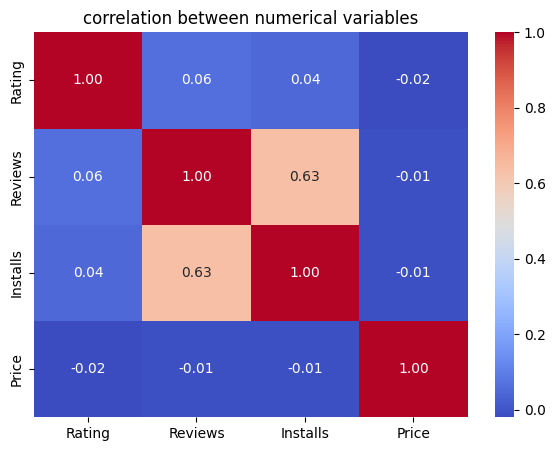

In [ ]:
plt.figure(figsize=(7,5))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('correlation between numerical variables')
plt.show()

In [ ]:
# Top 10 categories by number of apps

top_categories = df['Category'].value_counts().head(10)

print("Top 10 Categories by Number of Apps:")
print(top_categories)

Top 10 Categories by Number of Apps:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'FAMILY'),
  Text(1, 0, 'GAME'),
  Text(2, 0, 'TOOLS'),
  Text(3, 0, 'BUSINESS'),
  Text(4, 0, 'MEDICAL'),
  Text(5, 0, 'PRODUCTIVITY'),
  Text(6, 0, 'PERSONALIZATION'),
  Text(7, 0, 'LIFESTYLE'),
  Text(8, 0, 'COMMUNICATION'),
  Text(9, 0, 'FINANCE')])

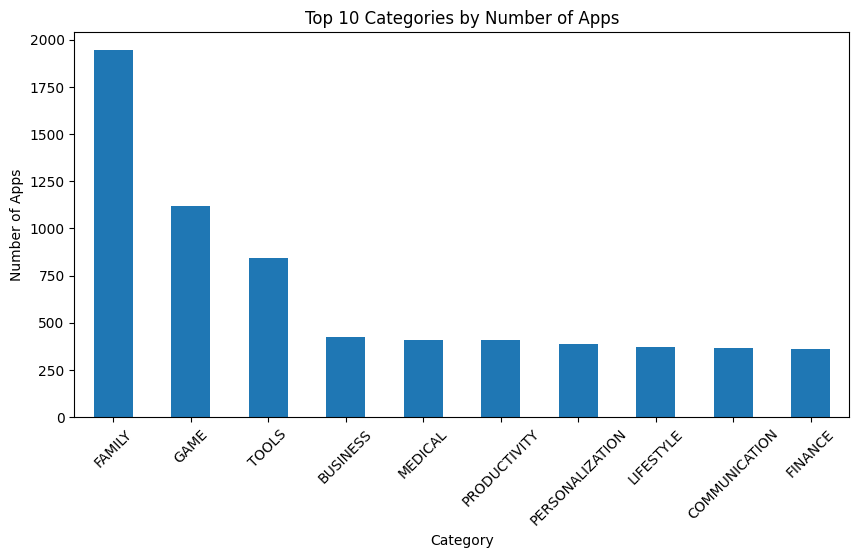

In [ ]:
plt.figure(figsize=(10, 5))

top_categories.plot(kind='bar')

plt.title('Top 10 Categories by Number of Apps')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

Free vs Paid Apps:
Type
Free       9591
Paid        765
Unknown       1
0             1
Name: count, dtype: int64


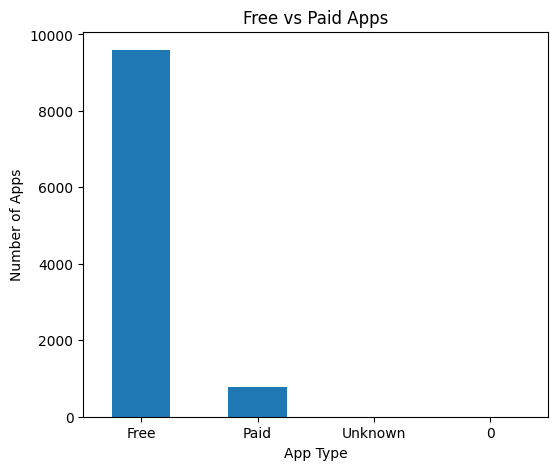

In [ ]:
# Free vs Paid Apps

type_count = df['Type'].value_counts()

print("Free vs Paid Apps:")
print(type_count)

plt.figure(figsize=(6,5))
type_count.plot(kind='bar')

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)
plt.show()

## **Insight: Paid apps have an average price of approximately 13.96 (in the dataset's price units).**

In [ ]:
# Average price of paid apps

paid_apps = df[df['Type'] == 'Paid']

average_paid_price = paid_apps['Price'].mean()

print("Average Price of Paid Apps:", round(average_paid_price,2))

Average Price of Paid Apps: 13.96


# **Most apps are rated Everyone, with 8,382 apps. Teen-rated apps are the second largest group with 1,146 apps. This shows that the Google Play Store mainly contains apps suitable for a general audience.**

In [ ]:
# Content rating analysis

content_rating = df['Content Rating'].value_counts()

print("Apps by Content Rating Analysis:")
print(content_rating)

Apps by Content Rating Analysis:
Content Rating
Everyone           8382
Teen               1146
Mature 17+          447
Everyone 10+        377
Adults only 18+       3
Unrated               2
Unknown               1
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Everyone'),
  Text(1, 0, 'Teen'),
  Text(2, 0, 'Mature 17+'),
  Text(3, 0, 'Everyone 10+'),
  Text(4, 0, 'Adults only 18+'),
  Text(5, 0, 'Unrated'),
  Text(6, 0, 'Unknown')])

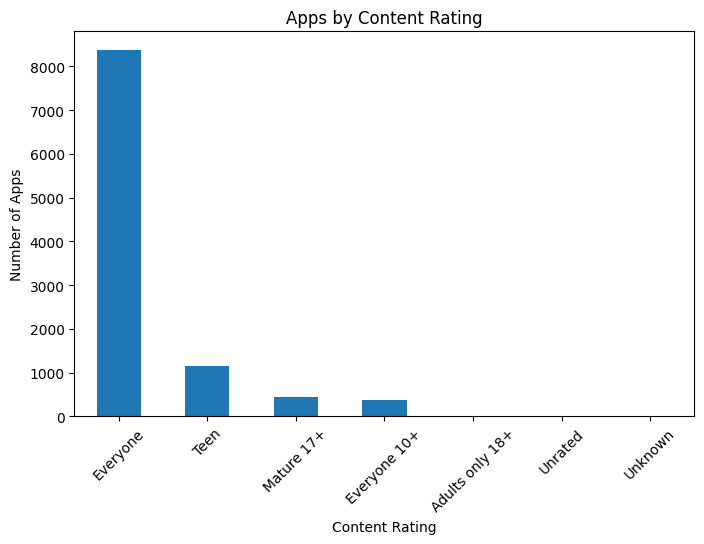

In [ ]:
# Content Rating Distribution

plt.figure(figsize=(8,5))

content_rating.plot(kind='bar')

plt.title('Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

In [ ]:
# Genres Analysis

genres_count = df['Genres'].value_counts().head(10)

print('Top 10 Genres:')
print(genres_count)

Top 10 Genres:
Genres
Tools              842
Entertainment      588
Education          527
Business           427
Medical            408
Productivity       407
Personalization    388
Lifestyle          372
Communication      366
Sports             364
Name: count, dtype: int64


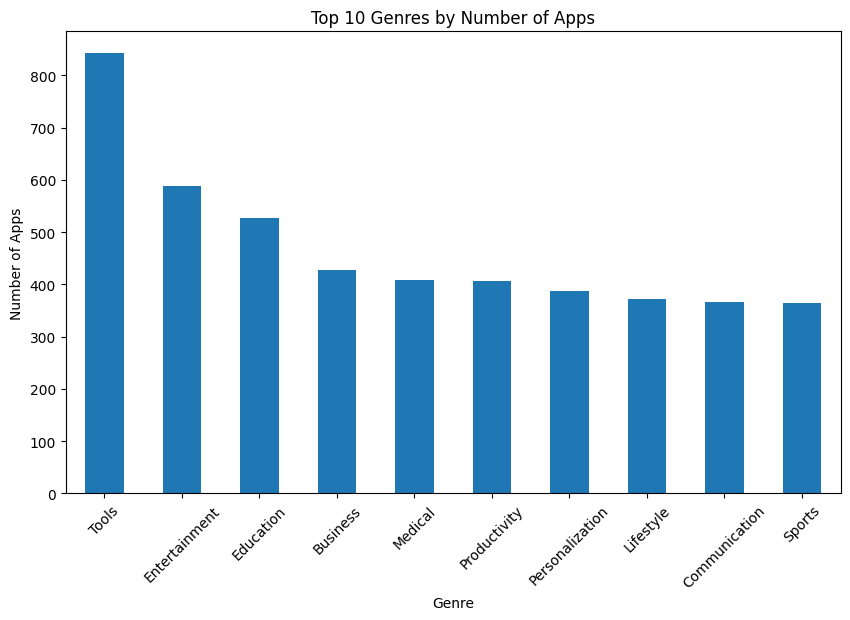

In [ ]:
# Genres Analysis - Top 10

plt.figure(figsize=(10,6))

genres_count.plot(kind='bar')

plt.title('Top 10 Genres by Number of Apps')
plt.xlabel('Genre')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

plt.show()

🔍 Insight – Genres Analysis
# **Tools is the most common genre among the top 10 genres, with 842 apps, followed by Entertainment with 588 apps and Education with 527 apps. This indicates strong representation of utility, entertainment, and education-related apps in the dataset.**

In [ ]:
# Average Rating by App Type

average_rating = df.groupby('Type')['Rating'].mean()

print("Average Rating by App Type:")
print(average_rating.round(2))

Average Rating by App Type:
Type
0          4.30
Free       4.20
Paid       4.27
Unknown    4.30
Name: Rating, dtype: float64













Installs Analysis
# **This analysis identifies the apps with the highest number of installations and helps understand user demand.**

In [ ]:
# Top 10 apps by number of installs

top_installs = df.sort_values('Installs', ascending=False).head(10)

print("Top 10 Apps by Number of Installs:")
print(top_installs[['App', 'Installs']])

Top 10 Apps by Number of Installs:
                            App      Installs
3454               Google Drive  1.000000e+09
865           Google Play Games  1.000000e+09
3523               Google Drive  1.000000e+09
2544                   Facebook  1.000000e+09
2545                  Instagram  1.000000e+09
464                    Hangouts  1.000000e+09
3223  Maps - Navigate & Explore  1.000000e+09
3816                Google News  1.000000e+09
4170               Google Drive  1.000000e+09
3896             Subway Surfers  1.000000e+09


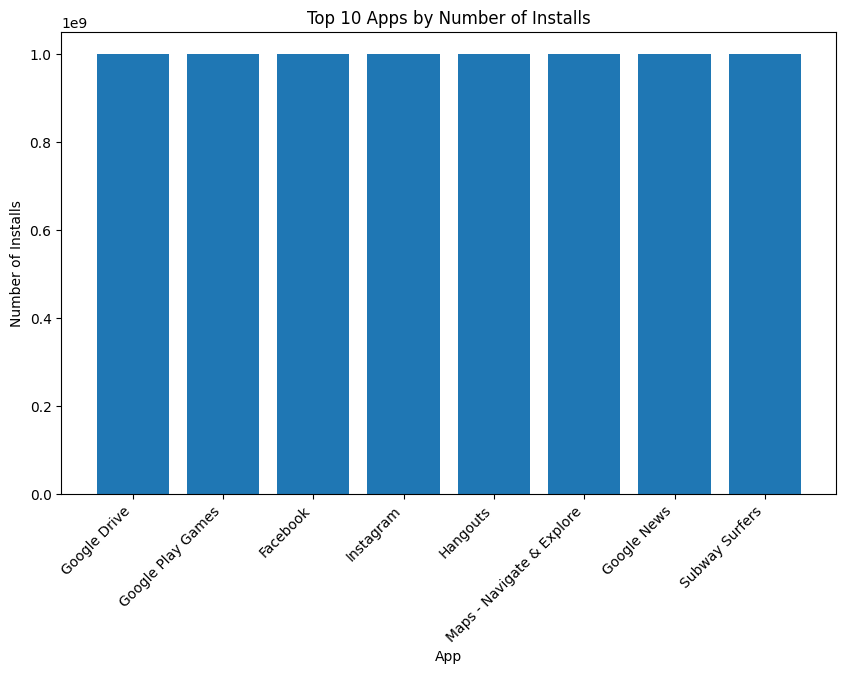

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(top_installs['App'], top_installs['Installs'])

plt.title('Top 10 Apps by Number of Installs')
plt.xlabel('App')
plt.ylabel('Number of Installs')
plt.xticks(rotation=45, ha='right')

plt.show()

Installs Analysis
# **The analysis shows that the top apps have very high numbers of installations, indicating strong user demand and popularity. Apps such as Google Drive, Google Photos, and other highly installed apps attract a large number of users. This suggests that popular and widely useful apps have a significant advantage in terms of downloads.**

Reviews Analysis
# **This analysis identifies the apps with the highest number of user reviews and helps understand user engagement.**

In [ ]:
# Top 10 apps by number of reviews

top_reviews = df.sort_values('Reviews', ascending=False).head(10)

print("Top 10 Apps by Number of Reviews:")
print(top_reviews[['App', 'Reviews']])

Top 10 Apps by Number of Reviews:
                                           App     Reviews
2544                                  Facebook  78158306.0
3943                                  Facebook  78128208.0
336                         WhatsApp Messenger  69119316.0
3904                        WhatsApp Messenger  69109672.0
2604                                 Instagram  66577446.0
2545                                 Instagram  66577313.0
3909                                 Instagram  66509917.0
382   Messenger – Text and Video Chat for Free  56646578.0
335   Messenger – Text and Video Chat for Free  56642847.0
1879                            Clash of Clans  44893888.0


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Facebook'),
  Text(1, 0, 'WhatsApp Messenger'),
  Text(2, 0, 'Instagram'),
  Text(3, 0, 'Messenger – Text and Video Chat for Free'),
  Text(4, 0, 'Clash of Clans')])

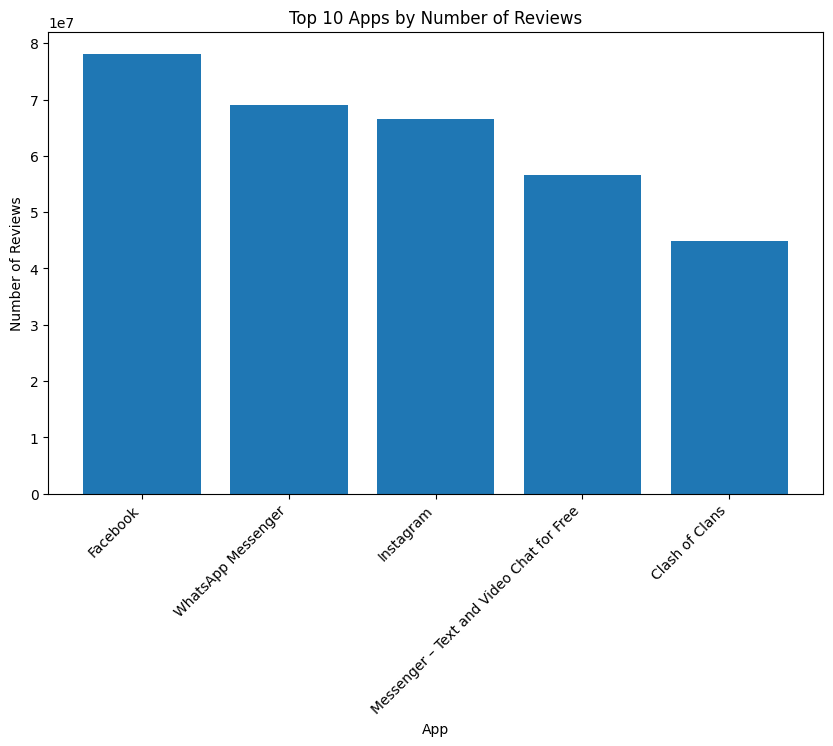

In [ ]:
plt.figure(figsize=(10,6))

plt.bar(top_reviews['App'], top_reviews['Reviews'])

plt.title('Top 10 Apps by Number of Reviews')
plt.xlabel('App')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')

Reviews Analysis
# **Facebook has the highest number of user reviews, followed by WhatsApp Messenger and Instagram. This indicates strong user engagement with popular communication and social media apps. Apps with a large user base generally receive more reviews and feedback.**

In [ ]:


# Price Analysis - Clean Price column

df['Price'] = df['Price'].astype(str).str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

print(df[['App', 'Price']].head(10))

                                                 App  Price
0     Photo Editor & Candy Camera & Grid & ScrapBook    0.0
1                                Coloring book moana    0.0
2  U Launcher Lite – FREE Live Cool Themes, Hide ...    0.0
3                              Sketch - Draw & Paint    0.0
4              Pixel Draw - Number Art Coloring Book    0.0
5                         Paper flowers instructions    0.0
6            Smoke Effect Photo Maker - Smoke Editor    0.0
7                                   Infinite Painter    0.0
8                               Garden Coloring Book    0.0
9                      Kids Paint Free - Drawing Fun    0.0


In [ ]:
# Free vs Paid Apps

df['App_Type'] = df['Price'].apply(lambda x: 'Free' if x == 0 else 'Paid')

type_count = df['App_Type'].value_counts()

print("Free vs Paid Apps:")
print(type_count)

Free vs Paid Apps:
App_Type
Free    9592
Paid     766
Name: count, dtype: int64


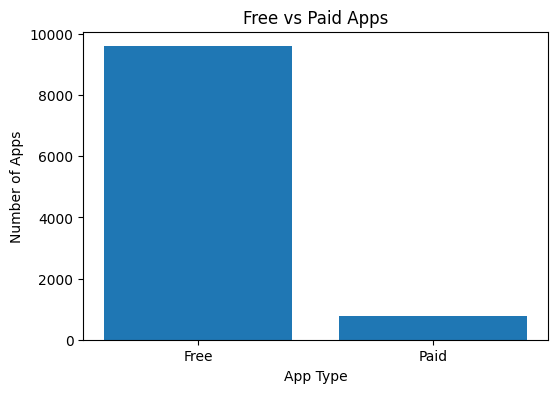

In [ ]:
# Free vs Paid Apps - Chart

plt.figure(figsize=(6,4))

plt.bar(type_count.index, type_count.values)

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')

plt.show()

Price Analysis – Insight
# **The dataset contains 9,592 free apps and 766 paid apps. Free apps are much more common than paid apps, showing that the Play Store dataset is dominated by free applications.**

In [ ]:
# Paid App Price Analysis

paid_apps = df[df['Price'] > 0]

top_expensive = paid_apps.sort_values(
    'Price', ascending=False
).head(10)

print("Top 10 Most Expensive Apps:")
print(top_expensive[['App', 'Price']])

Top 10 Most Expensive Apps:
                                    App   Price
4367           I'm Rich - Trump Edition  400.00
5356                  I Am Rich Premium  399.99
5369                          I am Rich  399.99
5351                          I am rich  399.99
5354                     I am Rich Plus  399.99
5358                         I am Rich!  399.99
4362                         💎 I'm rich  399.99
4197             most expensive app (H)  399.99
9934  I'm Rich/Eu sou Rico/أنا غني/我很有錢  399.99
5373                 I AM RICH PRO PLUS  399.99


/tmp/ipykernel_595/2073335559.py:12: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_595/2073335559.py:12: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_595/2073335559.py:12: UserWarning: Glyph 24456 (\N{CJK UNIFIED IDEOGRAPH-5F88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_595/2073335559.py:12: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_595/2073335559.py:12: UserWarning: Glyph 37666 (\N{CJK UNIFIED IDEOGRAPH-9322}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: User

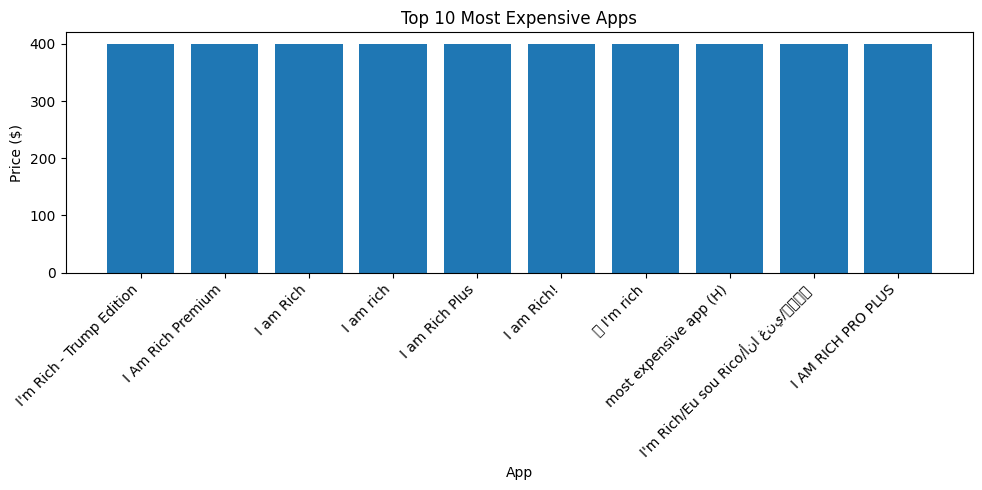

In [ ]:
# Top 10 Most Expensive Apps - Chart

plt.figure(figsize=(10, 5))

plt.bar(top_expensive['App'], top_expensive['Price'])

plt.title('Top 10 Most Expensive Apps')
plt.xlabel('App')
plt.ylabel('Price ($)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [ ]:
# size Analysis - clean size column

df['Size'] = df['Size'].astype(str).str.replace('M', '', regex=False)
df['Size'] = df['Size'].str.replace('k', '', regex=False)

df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

print(df[['App', 'Size']].head(10))

                                                 App  Size
0     Photo Editor & Candy Camera & Grid & ScrapBook  19.0
1                                Coloring book moana  14.0
2  U Launcher Lite – FREE Live Cool Themes, Hide ...   8.7
3                              Sketch - Draw & Paint  25.0
4              Pixel Draw - Number Art Coloring Book   2.8
5                         Paper flowers instructions   5.6
6            Smoke Effect Photo Maker - Smoke Editor  19.0
7                                   Infinite Painter  29.0
8                               Garden Coloring Book  33.0
9                      Kids Paint Free - Drawing Fun   3.1


In [ ]:
# Top 10 largest apps

top_size = df.sort_values('Size',ascending=False).head(10)

print("Top 10 Largest Apps:")
print(top_size[['App', 'Size']])

Top 10 Largest Apps:
                            App    Size
10798      Word Search Tab 1 FR  1020.0
8883                      DTPay   994.0
10402             FH Calculator   992.0
7868            CT - DTC Lookup   986.0
6798   Battery Notifier BT Free   982.0
9410            EI HabitTracker   981.0
2524    Super Ear Super Hearing   980.0
5783                Dynamics AX   976.0
2523                Fever Meter   975.0
9916                EU IP Codes   970.0


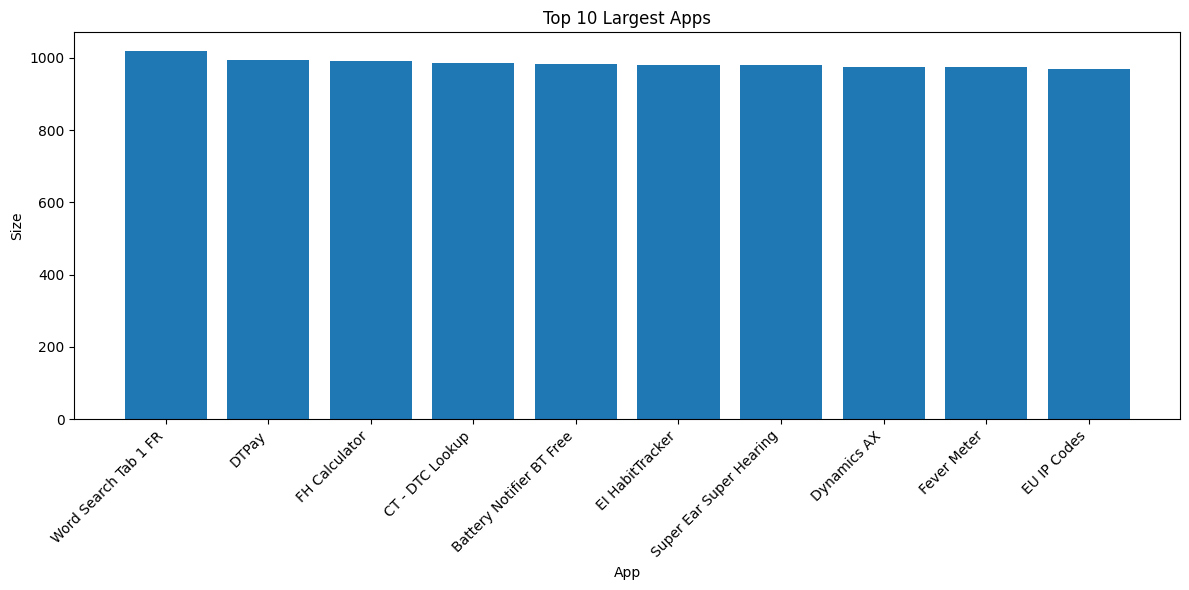

In [ ]:
# Top 10 Largest Apps - Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(top_size['App'], top_size['Size'])

plt.title('Top 10 Largest Apps')
plt.xlabel('App')
plt.ylabel('Size')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Size Analysis
# **The analysis identifies the apps with the largest file sizes. The top apps have sizes close to 1,000 MB, indicating that some applications require significant storage space. Larger apps may provide more features or content, but they also require more storage from users.**

In [ ]:
# #10 Installs Analysis - Clean Installs column

df['Installs'] = df['Installs'].astype(str).str.replace('+', '', regex=False)
df['Installs'] = df['Installs'].str.replace(',', '', regex=False)

df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

print(df[['App', 'Installs']].head(10))

                                                 App    Installs
0     Photo Editor & Candy Camera & Grid & ScrapBook     10000.0
1                                Coloring book moana    500000.0
2  U Launcher Lite – FREE Live Cool Themes, Hide ...   5000000.0
3                              Sketch - Draw & Paint  50000000.0
4              Pixel Draw - Number Art Coloring Book    100000.0
5                         Paper flowers instructions     50000.0
6            Smoke Effect Photo Maker - Smoke Editor     50000.0
7                                   Infinite Painter   1000000.0
8                               Garden Coloring Book   1000000.0
9                      Kids Paint Free - Drawing Fun     10000.0


In [ ]:
# Top 10 Most Installed Apps

top_installs = df.sort_values('Installs', ascending=False).head(10)

print("Top 10 Most Installed Apps:")
print(top_installs[['App', 'Installs']])

Top 10 Most Installed Apps:
                            App      Installs
3454               Google Drive  1.000000e+09
865           Google Play Games  1.000000e+09
3523               Google Drive  1.000000e+09
2544                   Facebook  1.000000e+09
2545                  Instagram  1.000000e+09
464                    Hangouts  1.000000e+09
3223  Maps - Navigate & Explore  1.000000e+09
3816                Google News  1.000000e+09
4170               Google Drive  1.000000e+09
3896             Subway Surfers  1.000000e+09


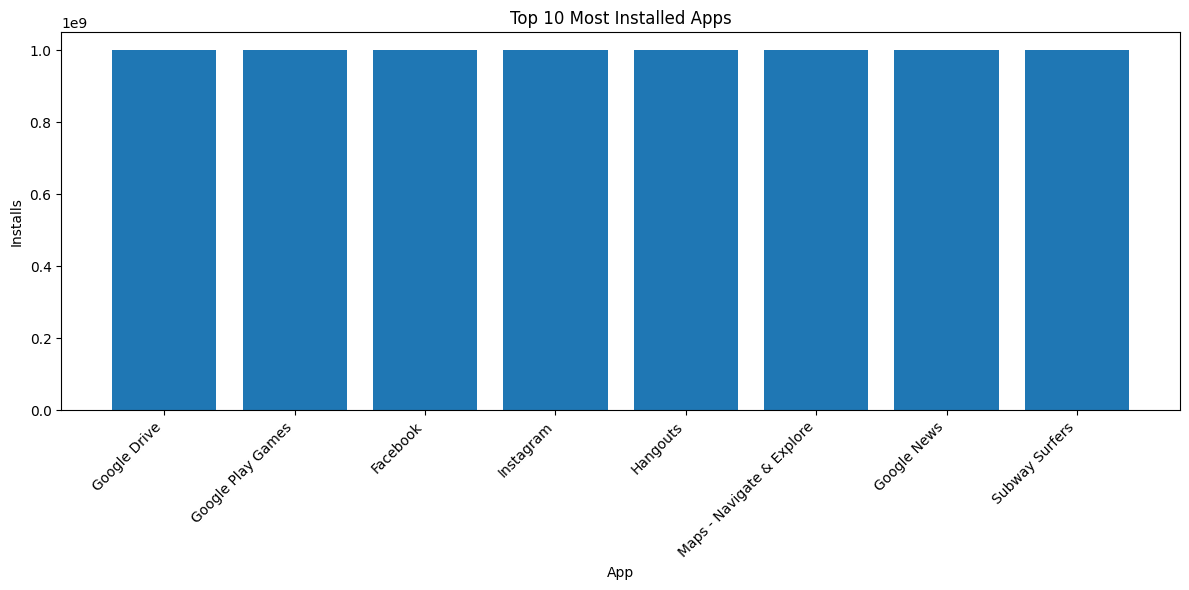

In [ ]:
# Top 10 Most Installed Apps - Chart

plt.figure(figsize=(12, 6))

plt.bar(top_installs['App'], top_installs['Installs'])

plt.title('Top 10 Most Installed Apps')
plt.xlabel('App')
plt.ylabel('Installs')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Installs Analysis
# **The analysis shows that several popular apps have extremely high installation counts, reaching around 1 billion installs. Apps such as Google Drive, Google Play Games, Facebook, Instagram, Hangouts, Google News, and Subway Surfers have very high user adoption. This indicates strong popularity and widespread usage of these applications.**

In [ ]:
# #11 Reviews Analysis

top_reviews = df.sort_values('Reviews', ascending=False).head(10)

print("Top 10 Apps by Reviews:")
print(top_reviews[['App', 'Reviews']])

Top 10 Apps by Reviews:
                                           App     Reviews
2544                                  Facebook  78158306.0
3943                                  Facebook  78128208.0
336                         WhatsApp Messenger  69119316.0
3904                        WhatsApp Messenger  69109672.0
2604                                 Instagram  66577446.0
2545                                 Instagram  66577313.0
3909                                 Instagram  66509917.0
382   Messenger – Text and Video Chat for Free  56646578.0
335   Messenger – Text and Video Chat for Free  56642847.0
1879                            Clash of Clans  44893888.0


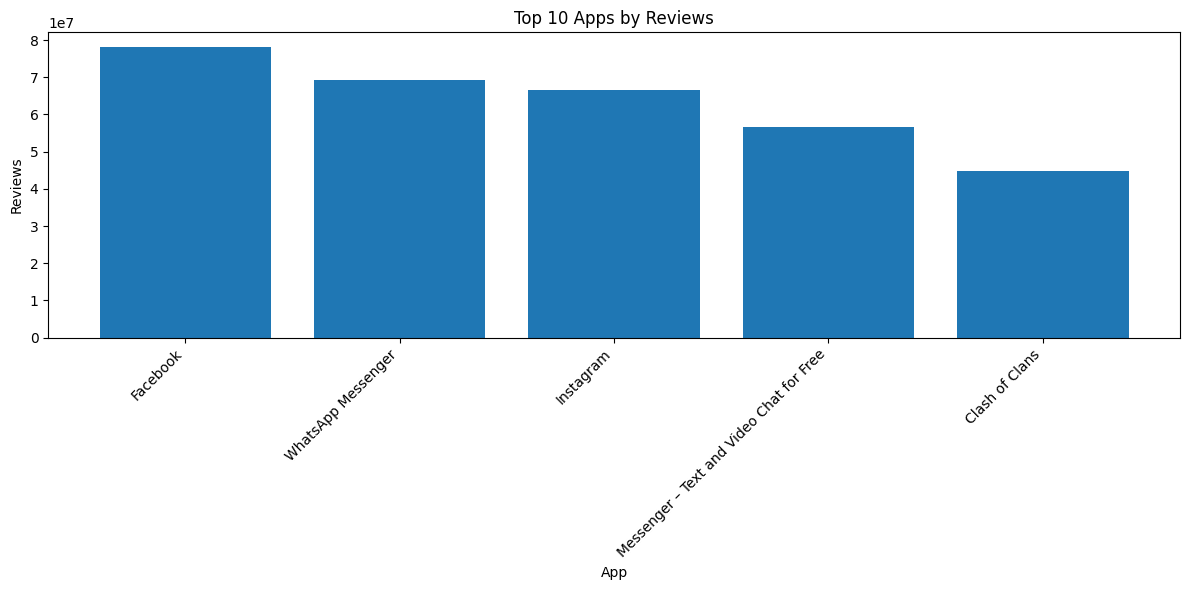

In [ ]:
# Top 10 Apps by Reviews - Chart

plt.figure(figsize=(12, 6))

plt.bar(top_reviews['App'], top_reviews['Reviews'])

plt.title('Top 10 Apps by Reviews')
plt.xlabel('App')
plt.ylabel('Reviews')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Reviews Analysis

# **The analysis shows that Facebook has the higest numbers of reviews among the top reviewed apps, followed by WhatsApps Messenger and Instagram. this indicates strong user engagement and Widespread usage of these applications.**

In [ ]:
# #12 Rating Analysis - Clean Rating column

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

print(df[['App', 'Rating']].head(10))

                                                 App  Rating
0     Photo Editor & Candy Camera & Grid & ScrapBook     4.1
1                                Coloring book moana     3.9
2  U Launcher Lite – FREE Live Cool Themes, Hide ...     4.7
3                              Sketch - Draw & Paint     4.5
4              Pixel Draw - Number Art Coloring Book     4.3
5                         Paper flowers instructions     4.4
6            Smoke Effect Photo Maker - Smoke Editor     3.8
7                                   Infinite Painter     4.1
8                               Garden Coloring Book     4.4
9                      Kids Paint Free - Drawing Fun     4.7


In [ ]:
# Top 10 Highest Rated Apps

top_ratings = df.sort_values('Rating', ascending=False).head(10)

print("Top 10 Highest Rated Apps:")
print(top_ratings[['App', 'Rating']])

Top 10 Highest Rated Apps:
                                                     App  Rating
10820                                    Fr. Daoud Lamei     5.0
10301  FD Calculator (EMI, SIP, RD & Loan Eligilibility)     5.0
10297                                      Story Time FD     5.0
10357                                         Ríos de Fe     5.0
10349                                    Santa Fe Thrive     5.0
7533                                            Color CL     5.0
7623                                         CN Resident     5.0
10266                              Noticias FC Barcelona     5.0
1547                                        Eternal life     5.0
10166                               FA Player Essentials     5.0


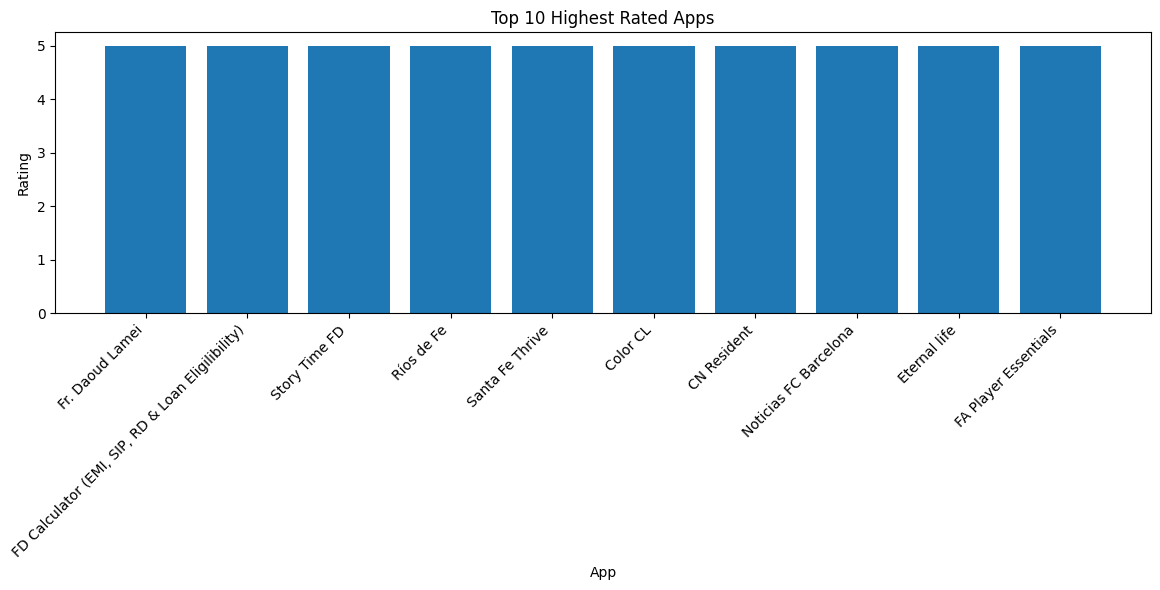

In [ ]:
# Top 10 Highest Rated Apps - Chart

plt.figure(figsize=(12, 6))

plt.bar(top_ratings['App'], top_ratings['Rating'])

plt.title('Top 10 Highest Rated Apps')
plt.xlabel('App')
plt.ylabel('Rating')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Rating Analysis
# **The analysis identifies the apps with the highest ratings. Highly rated apps indicate positive user feedback and satisfaction. These ratings can help understand which applications are well received by users.**

# **Overall Insights**

1.   Free apps have much higher user adoption than paid apps.
2.   Popular apps generally have very high installation numbers.
3.   Social and communication apps receive a large number of user reviews.
4.   Some apps have very large file sizes, which may require more storage space.
5.   Highly rated apps indicate positive user feedback.
6.   Overall, user engagement is stongly reflected through installs and reviews.







# **Final Conclusion**

*   **This project analyzes Google play store app data to understand app popularity, user engagement, ratings, pricing, and storage requirements. The analysis shows that free apps generally achieve higher installations, while popular social and communication apps receive a large number of reviews. The project also identifies highly rated apps and apps with large file sizes. these insights can help developers and businesses understand user preferences and improve their app strategies.**

